# CLEAR ATS — Uncertainty (Monte Carlo) notebook

This notebook runs the uncertainty calculation **directly in the notebook** (no `subprocess`, no Flask app).

Workflow:
1. load one scenario JSON (example: `california.json`)
2. load your model code from `footprint_model.py`
3. run Monte Carlo sampling (`mc_runs`)
4. compute P05 / P50 / P95 quantiles
5. plot the uncertainty band

If JSON has **no** `data_uncertainty` and no inline distribution specs, the band will collapse. This notebook can optionally inject a small example `data_uncertainty`.

In [16]:
# Cell 1 — setup
from pathlib import Path
import json
import copy
import io
import contextlib
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---- USER SETTINGS ----
# Change to your local config file
# CONFIG_PATH = r"C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\configs\california.json"
CONFIG_PATH = r"C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\configs\ohio.json"

# Years to simulate (68 means 2024..2092)
YEARS = 68

# Monte Carlo runs (set > 1 to get quantiles/bands)
MC_RUNS = 200

# RNG seed (reproducible)
SEED = 42

# Policy to apply: "baseline", "aggressive", "conservative", or "all"
POLICY_NAME = "all"

# If your JSON has no uncertainty specs, set True to inject a small example block.
ADD_EXAMPLE_UNCERTAINTY = True

# Output folder (default: <project_root>/results_notebook)
OUTPUT_DIR_NAME = "results_notebook"

In [17]:
# Cell 2 — locate project root and load your model module from footprint_model.py
config_path = Path(CONFIG_PATH)
if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

project_root = config_path.parent.parent  # .../CLEAR_ATS/CLEAR_ATS
model_path = project_root / "footprint_model.py"

if not model_path.exists():
    raise FileNotFoundError(
        "Cannot find footprint_model.py next to your configs folder.\n"
        f"Expected: {model_path}\n"
        "Fix: set model_path to the correct file."
    )

spec = importlib.util.spec_from_file_location("footprint_model", str(model_path))
fm = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(fm)

print("Loaded model from:", model_path)
print("Loaded config from:", config_path)
print("Project root:", project_root)

out_dir = project_root / OUTPUT_DIR_NAME
out_dir.mkdir(parents=True, exist_ok=True)
print("Output dir:", out_dir)

Loaded model from: C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\footprint_model.py
Loaded config from: C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\configs\ohio.json
Project root: C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS
Output dir: C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\results_notebook


In [18]:
# Cell 3 — load scenario config and apply policy override
with open(config_path, "r") as f:
    scenario_config = json.load(f)

policy_scenarios = scenario_config.get("policy_scenarios", {})
if POLICY_NAME == "all":
    policy_items = list(policy_scenarios.items()) if policy_scenarios else [("baseline", {})]
else:
    policy_patch = policy_scenarios.get(POLICY_NAME, {})
    policy_items = [(POLICY_NAME, policy_patch)]

print("Available policies:", list(policy_scenarios.keys()) if policy_scenarios else ["baseline"])
print("Selected:", [p for p, _ in policy_items])

Available policies: ['baseline', 'aggressive', 'conservative']
Selected: ['baseline', 'aggressive', 'conservative']


In [19]:
# # Cell 4 — (optional) inject example uncertainty if your JSON does not define any

# def inject_example_data_uncertainty(cfg):
#     '''
#     Adds a small data_uncertainty block to cfg in-place (returns cfg).
#     This is ONLY for getting a visible band quickly.
#     Adjust the distributions to match your own assumptions.
#     '''
#     cfg.setdefault("data_uncertainty", {})
#     du = cfg["data_uncertainty"]

#     # --- Initial state uncertainty ---
#     du.setdefault("initial_data", {})
#     du["initial_data"].setdefault(
#         "total_cars",
#         {"dist": "normal", "mean": cfg["initial_data"]["total_cars"], "sd": 500000, "min": 1, "integer": True},
#     )
#     du["initial_data"].setdefault(
#         "total_intersections",
#         {"dist": "normal", "mean": cfg["initial_data"]["total_intersections"], "sd": 20000, "min": 1, "integer": True},
#     )
#     du["initial_data"].setdefault(
#         "f_clean", {"dist": "beta", "mean": cfg["initial_data"]["f_clean"], "kappa": 60, "min": 0, "max": 1}
#     )

#     # EV share drives total_ev (your code uses ev_share -> total_ev = total_cars * ev_share)
#     base_ev_share = float(cfg["initial_data"]["total_ev"]) / float(cfg["initial_data"]["total_cars"])
#     du["initial_data"].setdefault(
#         "ev_share", {"dist": "normal", "mean": base_ev_share, "sd": 0.01, "min": 0, "max": 1}
#     )

#     # --- Growth rate uncertainty (small) ---
#     du.setdefault("growth_rates", {})
#     for k, rel_sd in [
#         ("ev", 0.15),
#         ("clean_energy", 0.20),
#         ("total_car_increase", 0.50),
#         ("efficiency_doubling", 0.10),
#     ]:
#         if k in cfg.get("growth_rates", {}):
#             mean = float(cfg["growth_rates"][k])
#             du["growth_rates"].setdefault(
#                 k, {"dist": "normal", "mean": mean, "sd": abs(mean) * rel_sd, "min": 0}
#             )

#     # --- Emission factor uncertainty ---
#     du.setdefault("emission_factors", {})
#     for k, rel_sd in [("e_clean", 0.30), ("e_fossil", 0.15), ("e_gasoline", 0.10)]:
#         if k in cfg.get("emission_factors", {}):
#             mean = float(cfg["emission_factors"][k])
#             du["emission_factors"].setdefault(
#                 k, {"dist": "lognormal", "mean": mean, "cv": rel_sd, "min": 0}
#             )

#     # --- Power table uncertainty (example: lognormal CV=10%) ---
#     du.setdefault("consumption_rates", {})

#     if "ecav_power" in cfg.get("consumption_rates", {}):
#         du["consumption_rates"].setdefault("ecav_power", {})
#         for lvl, triple in cfg["consumption_rates"]["ecav_power"].items():
#             du["consumption_rates"]["ecav_power"].setdefault(lvl, {})
#             for kk, vv in triple.items():
#                 du["consumption_rates"]["ecav_power"][lvl].setdefault(
#                     kk, {"dist": "lognormal", "mean": float(vv), "cv": 0.10, "min": 0}
#                 )

#     if "sti_power" in cfg.get("consumption_rates", {}):
#         du["consumption_rates"].setdefault("sti_power", {})
#         for lvl, triple in cfg["consumption_rates"]["sti_power"].items():
#             du["consumption_rates"]["sti_power"].setdefault(lvl, {})
#             for kk, vv in triple.items():
#                 du["consumption_rates"]["sti_power"][lvl].setdefault(
#                     kk, {"dist": "lognormal", "mean": float(vv), "cv": 0.10, "min": 0}
#                 )

#     return cfg

# def config_has_any_uncertainty(cfg):
#     return bool(cfg.get("data_uncertainty")) or fm.has_distribution_spec(cfg)

# if ADD_EXAMPLE_UNCERTAINTY and (not config_has_any_uncertainty(scenario_config)):
#     scenario_config = inject_example_data_uncertainty(scenario_config)
#     print("Injected example data_uncertainty into the loaded config.")
# else:
#     print("Using uncertainty settings already present in your config (or ADD_EXAMPLE_UNCERTAINTY=False).")

# print("has_distribution_spec =", fm.has_distribution_spec(scenario_config))
# print("has data_uncertainty =", bool(scenario_config.get("data_uncertainty")))
# Cell 4 — inject uncertainty blocks if your JSON does not define any

def inject_uncertainty_blocks(cfg):
    """
    Injects three uncertainty layers if missing.

    Layer A  today parameter uncertainty -> cfg["data_uncertainty"]
    Layer B  load uncertainty             -> cfg["model_variants"]["load_model"]
    Layer C  future tech uncertainty      -> cfg["model_variants"]["tech_model"]

    This is meant as a notebook-side starting point.
    Replace distribution widths with evidence-based values when available.
    """
    cfg = copy.deepcopy(cfg)

    # -----------------------------
    # Layer A: today parameter uncertainty
    # -----------------------------
    cfg.setdefault("data_uncertainty", {})
    du = cfg["data_uncertainty"]

    du.setdefault("initial_data", {})
    du["initial_data"].setdefault(
        "total_cars",
        {"dist": "normal", "mean": cfg["initial_data"]["total_cars"], "sd": 0.10 * cfg["initial_data"]["total_cars"],
         "min": 1, "integer": True},
    )
    du["initial_data"].setdefault(
        "total_intersections",
        {"dist": "normal", "mean": cfg["initial_data"]["total_intersections"], "sd": 0.10 * cfg["initial_data"]["total_intersections"],
         "min": 1, "integer": True},
    )
    du["initial_data"].setdefault(
        "f_clean",
        {"dist": "beta", "mean": cfg["initial_data"]["f_clean"], "kappa": 60, "min": 0, "max": 1},
    )

    # Use beta for a share rather than normal
    base_ev_share = float(cfg["initial_data"]["total_ev"]) / float(cfg["initial_data"]["total_cars"])
    du["initial_data"].setdefault(
        "ev_share",
        {"dist": "beta", "mean": base_ev_share, "kappa": 200, "min": 0, "max": 1},
    )

    du.setdefault("growth_rates", {})
    # Positive rates: lognormal is usually safer than normal
    for k, sigma in [
        ("ev", 0.25),
        ("clean_energy", 0.30),
        ("total_car_increase", 0.40),
        ("efficiency_doubling", 0.20),
    ]:
        if k in cfg.get("growth_rates", {}):
            med = float(cfg["growth_rates"][k])
            du["growth_rates"].setdefault(
                k, {"dist": "lognormal", "median": med, "sigma": sigma, "min": 0.0}
            )

    du.setdefault("emission_factors", {})
    for k, cv in [("e_clean", 0.30), ("e_fossil", 0.15), ("e_gasoline", 0.10)]:
        if k in cfg.get("emission_factors", {}):
            mean = float(cfg["emission_factors"][k])
            du["emission_factors"].setdefault(
                k, {"dist": "lognormal", "mean": mean, "cv": cv, "min": 0}
            )

    # Baseline table uncertainty for today measurement error and modeling error
    du.setdefault("consumption_rates", {})

    if "ecav_power" in cfg.get("consumption_rates", {}):
        du["consumption_rates"].setdefault("ecav_power", {})
        for lvl, triple in cfg["consumption_rates"]["ecav_power"].items():
            du["consumption_rates"]["ecav_power"].setdefault(lvl, {})
            for kk, vv in triple.items():
                du["consumption_rates"]["ecav_power"][lvl].setdefault(
                    kk, {"dist": "lognormal", "mean": float(vv), "cv": 0.10, "min": 0}
                )

    if "sti_power" in cfg.get("consumption_rates", {}):
        du["consumption_rates"].setdefault("sti_power", {})
        for lvl, triple in cfg["consumption_rates"]["sti_power"].items():
            du["consumption_rates"]["sti_power"].setdefault(lvl, {})
            for kk, vv in triple.items():
                du["consumption_rates"]["sti_power"][lvl].setdefault(
                    kk, {"dist": "lognormal", "mean": float(vv), "cv": 0.10, "min": 0}
                )

    # -----------------------------
    # Layer B: load uncertainty
    # -----------------------------
    cfg.setdefault("model_variants", {})
    mv = cfg["model_variants"]

    mv.setdefault("load_model", {})

    # Average utilization multipliers.
    # Median 1.0 means your current table is the reference load.
    mv["load_model"].setdefault(
        "cav_load",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.30, "min": 0.3, "max": 3.0},
    )
    mv["load_model"].setdefault(
        "sti_load",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.35, "min": 0.3, "max": 3.5},
    )

    # Exponents control which subsystem responds to load more strongly.
    # Example: communication tends to scale more with activity than sensing.
    mv["load_model"].setdefault(
        "exponent",
        {"sensing": 0.2, "computing": 1.0, "communication": 1.1},
    )

    # -----------------------------
    # Layer C: future tech uncertainty
    # -----------------------------
    mv.setdefault("tech_model", {})

    # These factors represent future non-compute improvements that your current
    # "efficiency_doubling" does not directly capture.
    mv["tech_model"].setdefault(
        "cav_sensor_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.25, "min": 0.4, "max": 1.8},
    )
    mv["tech_model"].setdefault(
        "cav_comm_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.30, "min": 0.4, "max": 2.2},
    )
    mv["tech_model"].setdefault(
        "sti_sensor_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.25, "min": 0.4, "max": 1.8},
    )
    mv["tech_model"].setdefault(
        "sti_comm_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.30, "min": 0.4, "max": 2.2},
    )

    # Optional: STI compute factor, to represent infrastructure compute hardware divergence
    # beyond what your global efficiency curve captures.
    mv["tech_model"].setdefault(
        "sti_compute_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.20, "min": 0.5, "max": 1.7},
    )

    return cfg


def config_has_any_uncertainty(cfg):
    return bool(cfg.get("data_uncertainty")) or fm.has_distribution_spec(cfg)

if ADD_EXAMPLE_UNCERTAINTY and (not config_has_any_uncertainty(scenario_config)):
    scenario_config = inject_uncertainty_blocks(scenario_config)
    print("Injected uncertainty blocks into the loaded config.")
else:
    print("Using uncertainty settings already present in your config (or ADD_EXAMPLE_UNCERTAINTY=False).")

print("has_distribution_spec =", fm.has_distribution_spec(scenario_config))
print("has data_uncertainty =", bool(scenario_config.get("data_uncertainty")))


Injected uncertainty blocks into the loaded config.
has_distribution_spec = True
has data_uncertainty = True


In [20]:
# Cell 5 — run Monte Carlo and compute quantiles (P05/P50/P95)
def apply_load_and_tech_to_power_tables(sampled_cfg):
    """
    Converts sampled load_model and tech_model into multipliers on the
    per-level power tables inside sampled_cfg["consumption_rates"].

    This changes the estimated CAV and STI energy demand under different load and tech cases.
    """
    mv = sampled_cfg.get("model_variants", {}) or {}
    load_model = mv.get("load_model", {}) or {}
    tech_model = mv.get("tech_model", {}) or {}

    cav_load = float(load_model.get("cav_load", 1.0))
    sti_load = float(load_model.get("sti_load", 1.0))
    expo = load_model.get("exponent", {}) or {}

    exp_s = float(expo.get("sensing", 0.0))
    exp_c = float(expo.get("computing", 0.0))
    exp_m = float(expo.get("communication", 0.0))

    cav_sensor_factor = float(tech_model.get("cav_sensor_factor", 1.0))
    cav_comm_factor = float(tech_model.get("cav_comm_factor", 1.0))
    sti_sensor_factor = float(tech_model.get("sti_sensor_factor", 1.0))
    sti_comm_factor = float(tech_model.get("sti_comm_factor", 1.0))
    sti_compute_factor = float(tech_model.get("sti_compute_factor", 1.0))

    cr = sampled_cfg.get("consumption_rates", {}) or {}

    if "ecav_power" in cr:
        for lvl, triple in cr["ecav_power"].items():
            triple["sensing"] = float(triple["sensing"]) * (cav_load ** exp_s) * cav_sensor_factor
            triple["computing"] = float(triple["computing"]) * (cav_load ** exp_c)
            triple["communication"] = float(triple["communication"]) * (cav_load ** exp_m) * cav_comm_factor

    if "sti_power" in cr:
        for lvl, triple in cr["sti_power"].items():
            triple["sensing"] = float(triple["sensing"]) * (sti_load ** exp_s) * sti_sensor_factor
            triple["computing"] = float(triple["computing"]) * (sti_load ** exp_c) * sti_compute_factor
            triple["communication"] = float(triple["communication"]) * (sti_load ** exp_m) * sti_comm_factor

    return sampled_cfg

def run_one(cfg, years, seed, model_variant=None):
    rng = np.random.default_rng(seed)
    use_sampling = bool(cfg.get("data_uncertainty")) or fm.has_distribution_spec(cfg)
    sampled = fm.sample_config(cfg, rng) if use_sampling else copy.deepcopy(cfg)

    # Ensure sampled keeps the scenario model_variants, not only "fixed_table"
    base_variant = fm._parse_model_variant("fixed_table")
    scenario_mv = sampled.get("model_variants", {}) or {}
    variant = fm._deep_merge(scenario_mv, base_variant)

    # Apply load and future tech multipliers to the sampled power tables
    sampled = apply_load_and_tech_to_power_tables(sampled)

    energy_model = fm.build_energy_model(variant, sampled["consumption_rates"])
    efficiency_model = variant.get("efficiency_model", "smooth")
    retrofit_share = variant.get("retrofit_share", 0.0)

    model = fm.TransportModel(
        sampled["initial_data"],
        sampled["growth_rates"],
        sampled["consumption_rates"],
        sampled["emission_factors"],
        model_variants=variant,
        energy_model=energy_model,
        efficiency_model=efficiency_model,
        retrofit_share=retrofit_share,
    )

    with contextlib.redirect_stdout(io.StringIO()):
        model.run_simulation(years=years)

    return model.results


def run_mc(cfg, years, mc_runs, seed0):
    runs = []
    for i in range(int(mc_runs)):
        runs.append(run_one(cfg, years, int(seed0) + i))
    return runs

quantiles = [0.05, 0.5, 0.95]

all_outputs = {}
for policy_name, policy_patch in policy_items:
    cfg_policy = fm._deep_merge(scenario_config, policy_patch)
    runs = run_mc(cfg_policy, YEARS, MC_RUNS, SEED)
    qdf = fm.compute_quantile_summary(runs, quantiles)

    # Save quantiles
    q_path = out_dir / f"california__policy-{policy_name}__quantiles.csv"
    qdf.to_csv(q_path, index=False)

    all_outputs[policy_name] = {"runs": runs, "qdf": qdf, "q_path": q_path}
    print(f"[{policy_name}] saved quantiles -> {q_path}")

# Show first rows for the selected policy
sel = POLICY_NAME if POLICY_NAME != "all" else list(all_outputs.keys())[0]
display(all_outputs[sel]["qdf"].head(10))

[baseline] saved quantiles -> C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\results_notebook\california__policy-baseline__quantiles.csv
[aggressive] saved quantiles -> C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\results_notebook\california__policy-aggressive__quantiles.csv
[conservative] saved quantiles -> C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\results_notebook\california__policy-conservative__quantiles.csv


,Year,ATS Total Power (kWh)_p05,ATS Total Power (kWh)_p50,ATS Total Power (kWh)_p95,CAV Total Power (kWh)_p05,CAV Total Power (kWh)_p50,CAV Total Power (kWh)_p95,ECAV Power (kWh)_p05,ECAV Power (kWh)_p50,ECAV Power (kWh)_p95,...,Incremented Car Number_p95,EV Fraction_p05,EV Fraction_p50,EV Fraction_p95,Clean Energy Fraction_p05,Clean Energy Fraction_p50,Clean Energy Fraction_p95,Cumulative New Cars_p05,Cumulative New Cars_p50,Cumulative New Cars_p95
0,2024,4.022400e+05,7.590576e+05,1.303915e+06,4.022400e+05,7.590576e+05,1.303915e+06,0.000000,1.929953e+03,7.024172e+03,...,0.000000,0.000472,0.004662,0.013120,0.290112,0.395805,0.504642,4.000000e+02,4.000000e+02,4.000000e+02
1,2025,8.079124e+07,1.212297e+08,1.852577e+08,3.045763e+07,5.193634e+07,8.599030e+07,18232.980920,1.544932e+05,4.868415e+05,...,807028.552349,0.000489,0.004958,0.013866,0.302828,0.416392,0.533268,5.830399e+05,6.874897e+05,8.074261e+05
2,2026,1.711997e+08,2.593324e+08,3.877102e+08,7.848134e+07,1.324498e+08,2.192704e+08,52837.457035,4.279889e+05,1.344377e+06,...,807069.583002,0.000506,0.005261,0.014655,0.319462,0.437318,0.563251,1.165701e+06,1.374637e+06,1.614492e+06
3,2027,2.585946e+08,4.071090e+08,6.133026e+08,1.321334e+08,2.292347e+08,3.896786e+08,96825.602974,7.954276e+05,2.508966e+06,...,807111.137949,0.000536,0.005620,0.015490,0.342255,0.455069,0.593299,1.748384e+06,2.061842e+06,2.421599e+06
4,2028,3.410084e+08,5.487809e+08,8.116601e+08,1.898526e+08,3.318899e+08,5.687337e+08,151108.343320,1.242192e+06,3.910640e+06,...,807153.406759,0.000569,0.006141,0.016435,0.362148,0.479005,0.617282,2.331089e+06,2.749106e+06,3.228745e+06
5,2029,4.177009e+08,6.814198e+08,1.007701e+09,2.442315e+08,4.357431e+08,7.307925e+08,207191.634404,1.740538e+06,5.507715e+06,...,807196.660175,0.000603,0.006504,0.017741,0.378772,0.503619,0.656705,2.913815e+06,3.436427e+06,4.035932e+06
6,2030,4.803443e+08,8.076460e+08,1.222747e+09,2.956320e+08,5.313212e+08,8.820198e+08,266439.410848,2.258719e+06,7.272008e+06,...,807241.284902,0.000640,0.007010,0.019151,0.395709,0.524612,0.705245,3.496562e+06,4.123807e+06,4.843159e+06
7,2031,5.365723e+08,9.266172e+08,1.412246e+09,3.408264e+08,6.202227e+08,1.053480e+09,327979.293678,2.846083e+06,9.192338e+06,...,807287.833299,0.000680,0.007593,0.020672,0.413073,0.552403,0.760908,4.079332e+06,4.811245e+06,5.650426e+06
8,2032,5.917903e+08,1.037924e+09,1.588187e+09,3.897765e+08,6.997184e+08,1.220366e+09,392619.264184,3.406460e+06,1.128333e+07,...,807337.094380,0.000722,0.008228,0.022314,0.427015,0.581729,0.813356,4.662123e+06,5.498742e+06,6.457734e+06
9,2033,6.417304e+08,1.140729e+09,1.737257e+09,4.316198e+08,7.819826e+08,1.377700e+09,457892.213343,3.968385e+06,1.349857e+07,...,807390.195234,0.000766,0.008824,0.024050,0.443411,0.608958,0.860747,5.244936e+06,6.186298e+06,7.265082e+06


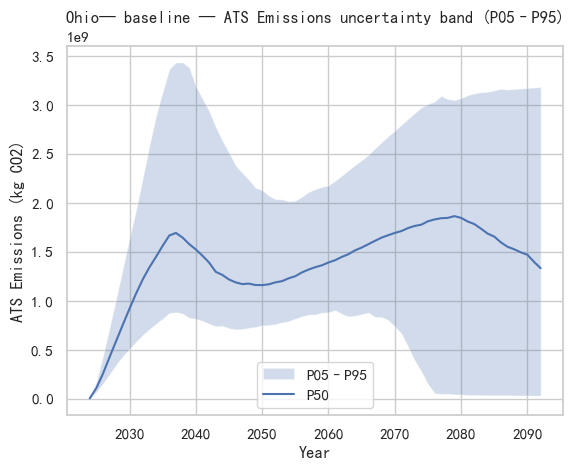

In [21]:
# Cell 6 — plot uncertainty band (example: ATS Emissions)

def plot_band(qdf, base_col, title):
    years = qdf["Year"].to_numpy()
    p05 = qdf[f"{base_col}_p05"].to_numpy()
    p50 = qdf[f"{base_col}_p50"].to_numpy()
    p95 = qdf[f"{base_col}_p95"].to_numpy()

    plt.figure()
    plt.fill_between(years, p05, p95, alpha=0.25, label="P05–P95")
    plt.plot(years, p50, label="P50")
    plt.xlabel("Year")
    plt.ylabel(base_col)
    plt.title(title)
    plt.legend()
    plt.show()

sel = POLICY_NAME if POLICY_NAME != "all" else list(all_outputs.keys())[0]
qdf = all_outputs[sel]["qdf"]

plot_band(
    qdf,
    base_col="ATS Emissions (kg CO2)",
    title=f"Ohio— {sel} — ATS Emissions uncertainty band (P05–P95)",
)

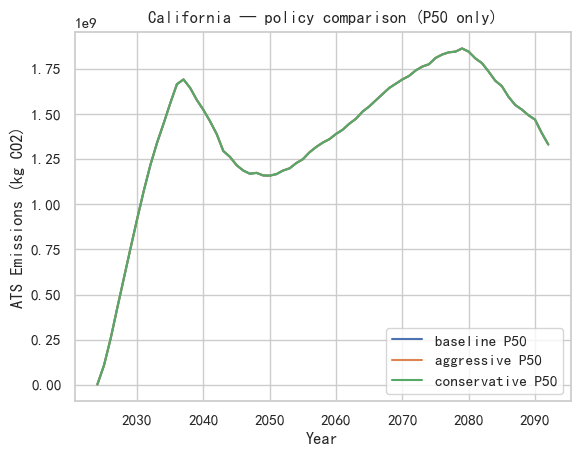

In [22]:
# Cell 7 — optional: compare P50 across policies
if len(all_outputs) > 1:
    base_col = "ATS Emissions (kg CO2)"
    plt.figure()
    for policy_name, obj in all_outputs.items():
        qdf = obj["qdf"]
        years = qdf["Year"].to_numpy()
        p50 = qdf[f"{base_col}_p50"].to_numpy()
        plt.plot(years, p50, label=f"{policy_name} P50")
    plt.xlabel("Year")
    plt.ylabel(base_col)
    plt.title("California — policy comparison (P50 only)")
    plt.legend()
    plt.show()
else:
    print("Only one policy selected; nothing to compare.")


Layer 1: data uncertainty only
Active uncertainty blocks in cfg['data_uncertainty'] are:
initial_data, emission_factors

Meaning of data uncertainty in this layer
initial_data changes the starting scale such as vehicles, intersections, and clean_share.
emission_factors changes the conversion from energy to CO2 for clean, fossil, and gasoline.

Parameter distributions used in this layer

Block 'initial_data' has 4 uncertain parameters.
                      param_path   dist         mean       sd  min  max  cv
           initial_data.ev_share   beta 5.936250e-03      NaN    0  1.0 NaN
            initial_data.f_clean   beta 3.900000e-01      NaN    0  1.0 NaN
         initial_data.total_cars normal 8.000000e+06 800000.0    1  NaN 0.1
initial_data.total_intersections normal 1.710000e+05  17100.0    1  NaN 0.1

Block 'emission_factors' has 3 uncertain parameters.
                 param_path      dist  mean   sd  min  max  cv
   emission_factors.e_clean lognormal  0.03 None    0 None NaN


C:\Users\17264\AppData\Local\Temp\ipykernel_35448\3819024789.py:143: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat(all_tables, axis=0).reset_index(drop=True)
C:\Users\17264\AppData\Local\Temp\ipykernel_35448\3819024789.py:143: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat(all_tables, axis=0).reset_index(drop=True)
C:\Users\17264\AppData\Local\Temp\ipykernel_35448\3819024789.py:143: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA e

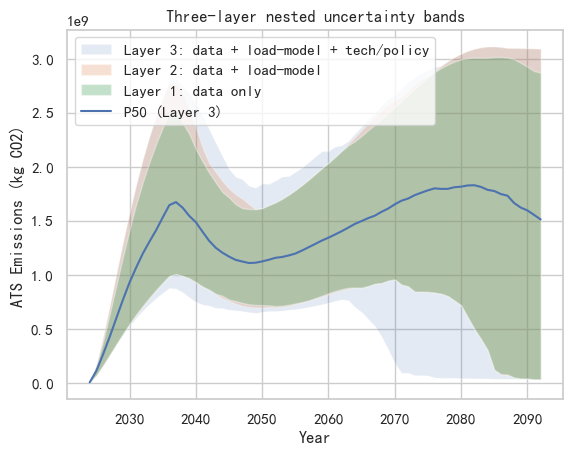


------------------------------------------------------------------------------------------
How the uncertainty band grows when you add more layers
------------------------------------------------------------------------------------------

Year 2035
Layer 1 width (data only)                : 1.436e+09
Layer 2 width (adds load-model)          : 1.709e+09
Layer 3 width (adds tech and policy)     : 1.802e+09
Added by load-model (Layer 2 - Layer 1)  : 2.730e+08
Added by tech and policy (Layer 3 - Layer 2): 9.288e+07

Year 2050
Layer 1 width (data only)                : 8.979e+08
Layer 2 width (adds load-model)          : 9.199e+08
Layer 3 width (adds tech and policy)     : 1.189e+09
Added by load-model (Layer 2 - Layer 1)  : 2.198e+07
Added by tech and policy (Layer 3 - Layer 2): 2.688e+08

Year 2075
Layer 1 width (data only)                : 1.989e+09
Layer 2 width (adds load-model)          : 1.995e+09
Layer 3 width (adds tech and policy)     : 2.832e+09
Added by load-model (Layer 2 - La

In [ ]:
# Cell X — three-layer (nested) uncertainty bands + readable layer diagnostics
import copy
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
    _HAS_PANDAS = True
except Exception:
    _HAS_PANDAS = False


# ----------------------------
# 1) Layer config builder
# ----------------------------
def build_layer_cfg(cfg_base, keep_initial=True, keep_emissions=True, keep_load=False, keep_tech=False):
    """
    Layer 1 (data uncertainty): initial_data + emission_factors
    Layer 2 (load-model uncertainty): Layer 1 + consumption_rates
    Layer 3 (tech/policy uncertainty): Layer 2 + growth_rates
    """
    cfg = copy.deepcopy(cfg_base)
    du = cfg.get("data_uncertainty", {}) or {}

    du_new = {}
    if keep_initial and "initial_data" in du:
        du_new["initial_data"] = du["initial_data"]
    if keep_emissions and "emission_factors" in du:
        du_new["emission_factors"] = du["emission_factors"]
    if keep_load and "consumption_rates" in du:
        du_new["consumption_rates"] = du["consumption_rates"]
    if keep_tech and "growth_rates" in du:
        du_new["growth_rates"] = du["growth_rates"]

    cfg["data_uncertainty"] = du_new
    return cfg


# ----------------------------
# 2) Introspection utilities
# ----------------------------
def _is_dist_leaf(x):
    # A leaf follows your schema if it has dist + bounds, and usually mean/sd
    return isinstance(x, dict) and ("dist" in x) and (
        ("mean" in x) or ("sd" in x) or ("min" in x) or ("max" in x)
    )

def iter_dist_leaves(obj, prefix=""):
    """
    Yields (path, spec_dict) for every distribution leaf in nested dicts.
    """
    if _is_dist_leaf(obj):
        yield prefix, obj
        return
    if isinstance(obj, dict):
        for k, v in obj.items():
            new_prefix = f"{prefix}.{k}" if prefix else str(k)
            yield from iter_dist_leaves(v, new_prefix)

def summarize_du_block(du_block, block_name):
    """
    Returns a table-like object listing all parameters and their distribution specs.
    """
    rows = []
    for path, spec in iter_dist_leaves(du_block, prefix=block_name):
        rows.append({
            "param_path": path,
            "dist": spec.get("dist", None),
            "mean": spec.get("mean", None),
            "sd": spec.get("sd", None),
            "min": spec.get("min", None),
            "max": spec.get("max", None),
        })

    if _HAS_PANDAS:
        return pd.DataFrame(rows).sort_values("param_path").reset_index(drop=True)
    return rows

def describe_layer(cfg, layer_name, max_rows=40):
    """
    Prints a plain-words report of what is uncertain in this layer and how it is modeled.
    """
    du = cfg.get("data_uncertainty", {}) or {}
    active_blocks = list(du.keys())

    print("\n" + "=" * 90)
    print(f"{layer_name}")
    print("=" * 90)
    if not active_blocks:
        print("No uncertainty blocks are active in cfg['data_uncertainty'].")
        return

    print("Active uncertainty blocks in cfg['data_uncertainty'] are:")
    print(", ".join(active_blocks))

    # Explain meaning in plain words
    if "initial_data" in active_blocks or "emission_factors" in active_blocks:
        print("\nMeaning of data uncertainty in this layer")
        print("initial_data changes the starting scale such as vehicles, intersections, and clean_share.")
        print("emission_factors changes the conversion from energy to CO2 for clean, fossil, and gasoline.")

    if "consumption_rates" in active_blocks:
        print("\nMeaning of load-model uncertainty in this layer")
        print("consumption_rates changes the baseline annual energy terms for propulsion, sensing, communication, and computing.")
        print("This is where you encode idle energy, DVFS variation, duty-cycle mismatch, and datasheet worst-case versus typical operation.")
        print("In practice, each draw perturbs the per-level subsystem energy values that your simulator uses each year.")

    if "growth_rates" in active_blocks:
        print("\nMeaning of tech and policy trajectory uncertainty in this layer")
        print("growth_rates changes long-horizon evolution such as fleet growth, electrification, clean_share growth, ATS penetration, and efficiency doubling year.")
        print("This changes the shape of the time series, not only the scale of one year.")

    # Print parameter tables
    print("\nParameter distributions used in this layer")
    all_tables = []
    for block in active_blocks:
        tbl = summarize_du_block(du[block], block_name=block)
        all_tables.append(tbl)

        if _HAS_PANDAS:
            print(f"\nBlock '{block}' has {len(tbl)} uncertain parameters.")
            display_tbl = tbl.copy()
            # add a quick coefficient-of-variation column when possible
            display_tbl["cv"] = np.where(
                (display_tbl["mean"].notna()) & (display_tbl["sd"].notna()) & (display_tbl["mean"] != 0),
                display_tbl["sd"] / display_tbl["mean"],
                np.nan
            )
            if len(display_tbl) > max_rows:
                print(display_tbl.head(max_rows).to_string(index=False))
                print(f"... showing first {max_rows} rows")
            else:
                print(display_tbl.to_string(index=False))
        else:
            print(f"\nBlock '{block}' has {len(tbl)} uncertain parameters.")
            for r in tbl[:max_rows]:
                print(r)
            if len(tbl) > max_rows:
                print(f"... showing first {max_rows} rows")

    # Return a merged table if pandas exists, for optional later use
    if _HAS_PANDAS and all_tables:
        merged = pd.concat(all_tables, axis=0).reset_index(drop=True)
        return merged
    return None


# ----------------------------
# 3) Monte Carlo utilities
# ----------------------------
def run_mc_with_trial_seeds(cfg, years, trial_seeds):
    """
    Uses the same list of trial seeds for all layers.
    This makes the three bands comparable as nested uncertainty intervals.
    """
    runs = []
    for s in trial_seeds:
        runs.append(run_one(cfg, years, int(s)))
    return runs

def enforce_nested(q1, q2, q3, base_col):
    lo1, hi1 = q1[f"{base_col}_p05"].to_numpy(), q1[f"{base_col}_p95"].to_numpy()
    lo2, hi2 = q2[f"{base_col}_p05"].to_numpy(), q2[f"{base_col}_p95"].to_numpy()
    lo3, hi3 = q3[f"{base_col}_p05"].to_numpy(), q3[f"{base_col}_p95"].to_numpy()

    lo2 = np.minimum(lo2, lo1); hi2 = np.maximum(hi2, hi1)
    lo3 = np.minimum(lo3, lo2); hi3 = np.maximum(hi3, hi2)

    q2[f"{base_col}_p05"] = lo2; q2[f"{base_col}_p95"] = hi2
    q3[f"{base_col}_p05"] = lo3; q3[f"{base_col}_p95"] = hi3
    return q1, q2, q3

def plot_three_layer(q1, q2, q3, base_col, title):
    years = q1["Year"].to_numpy()

    plt.figure()
    plt.fill_between(years, q3[f"{base_col}_p05"], q3[f"{base_col}_p95"], alpha=0.15,
                     label="Layer 3: data + load-model + tech/policy")
    plt.fill_between(years, q2[f"{base_col}_p05"], q2[f"{base_col}_p95"], alpha=0.25,
                     label="Layer 2: data + load-model")
    plt.fill_between(years, q1[f"{base_col}_p05"], q1[f"{base_col}_p95"], alpha=0.35,
                     label="Layer 1: data only")
    plt.plot(years, q3[f"{base_col}_p50"], label="P50 (Layer 3)")

    plt.xlabel("Year")
    plt.ylabel(base_col)
    plt.title(title)
    plt.legend()
    plt.show()

def print_band_widening(q1, q2, q3, base_col, years_of_interest=None):
    """
    Prints how much each added layer widens the 90 percent interval (p95 - p05).
    """
    if years_of_interest is None:
        years_of_interest = []

    years = q1["Year"].to_numpy()
    w1 = (q1[f"{base_col}_p95"] - q1[f"{base_col}_p05"]).to_numpy()
    w2 = (q2[f"{base_col}_p95"] - q2[f"{base_col}_p05"]).to_numpy()
    w3 = (q3[f"{base_col}_p95"] - q3[f"{base_col}_p05"]).to_numpy()

    add_load = w2 - w1
    add_tech = w3 - w2

    print("\n" + "-" * 90)
    print("How the uncertainty band grows when you add more layers")
    print("-" * 90)

    def _closest_idx(y):
        return int(np.argmin(np.abs(years - y)))

    if years_of_interest:
        for y in years_of_interest:
            i = _closest_idx(y)
            print(f"\nYear {int(years[i])}")
            print(f"Layer 1 width (data only)                : {w1[i]:.3e}")
            print(f"Layer 2 width (adds load-model)          : {w2[i]:.3e}")
            print(f"Layer 3 width (adds tech and policy)     : {w3[i]:.3e}")
            print(f"Added by load-model (Layer 2 - Layer 1)  : {add_load[i]:.3e}")
            print(f"Added by tech and policy (Layer 3 - Layer 2): {add_tech[i]:.3e}")
    else:
        # Summary over the whole horizon
        print(f"Median width over time, Layer 1: {np.median(w1):.3e}")
        print(f"Median width over time, Layer 2: {np.median(w2):.3e}")
        print(f"Median width over time, Layer 3: {np.median(w3):.3e}")
        print(f"Median added by load-model: {np.median(add_load):.3e}")
        print(f"Median added by tech and policy: {np.median(add_tech):.3e}")


# ----------------------------
# 4) Example usage with your notebook variables
# ----------------------------
cfg0 = scenario_config  # already in your notebook

# One shared seed list for all three layers
trial_seeds = np.random.default_rng(SEED).integers(0, 2**32 - 1, size=int(MC_RUNS), dtype=np.uint32)

cfg_L1 = build_layer_cfg(cfg0, keep_initial=True, keep_emissions=True, keep_load=False, keep_tech=False)
cfg_L2 = build_layer_cfg(cfg0, keep_initial=True, keep_emissions=True, keep_load=True,  keep_tech=False)
cfg_L3 = build_layer_cfg(cfg0, keep_initial=True, keep_emissions=True, keep_load=True,  keep_tech=True)

# Print human-readable “what is in each layer”
tbl1 = describe_layer(cfg_L1, "Layer 1: data uncertainty only")
tbl2 = describe_layer(cfg_L2, "Layer 2: data + load-model uncertainty")
tbl3 = describe_layer(cfg_L3, "Layer 3: data + load-model + tech/policy uncertainty")

# Run MC
runs1 = run_mc_with_trial_seeds(cfg_L1, YEARS, trial_seeds)
runs2 = run_mc_with_trial_seeds(cfg_L2, YEARS, trial_seeds)
runs3 = run_mc_with_trial_seeds(cfg_L3, YEARS, trial_seeds)

quantiles = [0.05, 0.5, 0.95]
q1 = fm.compute_quantile_summary(runs1, quantiles)
q2 = fm.compute_quantile_summary(runs2, quantiles)
q3 = fm.compute_quantile_summary(runs3, quantiles)

base_col = "ATS Emissions (kg CO2)"  # change if your column name differs

# Guarantee nesting for presentation
q1, q2, q3 = enforce_nested(q1, q2, q3, base_col)

# Plot
plot_three_layer(q1, q2, q3, base_col, title="Three-layer nested uncertainty bands")

# Print how each layer widens the band at a few years
print_band_widening(q1, q2, q3, base_col, years_of_interest=[2035, 2050, 2075, 2090])


In [26]:
import numpy as np
import pandas as pd
import math

def _infer_lognormal_mu_sigma(spec):
    # Accept either (mu, sigma) or (mean, cv)
    if spec.get("mu") is not None and spec.get("sigma") is not None:
        return float(spec["mu"]), float(spec["sigma"])
    mean = spec.get("mean")
    cv = spec.get("cv")
    if mean is None or cv is None:
        return None, None
    mean = float(mean); cv = float(cv)
    sigma = math.sqrt(math.log(cv * cv + 1.0))
    mu = math.log(mean) - 0.5 * sigma * sigma
    return mu, sigma

def _infer_beta_ab(spec):
    # Accept either (a, b) or (mean, kappa)
    if spec.get("a") is not None and spec.get("b") is not None:
        return float(spec["a"]), float(spec["b"])
    mean = spec.get("mean")
    kappa = spec.get("kappa")
    if mean is None or kappa is None:
        return None, None
    mean = float(mean); kappa = float(kappa)
    a = mean * kappa
    b = (1.0 - mean) * kappa
    return a, b

def _sample_param(rng, spec, n=50000):
    dist = spec.get("dist")

    if dist == "normal":
        mean = float(spec["mean"]); sd = float(spec["sd"])
        x = rng.normal(mean, sd, size=n)

    elif dist == "beta":
        a, b = _infer_beta_ab(spec)
        if a is None:
            x = np.full(n, float(spec.get("mean", np.nan)))
        else:
            x = rng.beta(a, b, size=n)

    elif dist == "lognormal":
        mu, sigma = _infer_lognormal_mu_sigma(spec)
        if mu is None:
            x = np.full(n, float(spec.get("mean", np.nan)))
        else:
            x = rng.lognormal(mean=mu, sigma=sigma, size=n)

    else:
        x = np.full(n, float(spec.get("mean", np.nan)))

    # Truncation
    if spec.get("min") is not None:
        x = np.maximum(x, float(spec["min"]))
    if spec.get("max") is not None:
        x = np.minimum(x, float(spec["max"]))

    # Optional integer rounding (your config often uses this for counts)
    if spec.get("integer", False):
        x = np.round(x).astype(float)

    return x

def _flatten_uncertainty(du):
    rows = []
    def rec(prefix, obj):
        if isinstance(obj, dict):
            # Leaf param spec
            if "dist" in obj:
                rows.append((prefix, obj))
                return
            for k, v in obj.items():
                rec(f"{prefix}.{k}" if prefix else k, v)
    rec("", du)
    return rows

def summarize_uncertainty(cfg, n=50000, seed=0):
    du = cfg.get("data_uncertainty", {}) or {}
    flat = _flatten_uncertainty(du)

    rng = np.random.default_rng(seed)
    out = []
    for path, spec in flat:
        x = _sample_param(rng, spec, n=n)
        out.append({
            "param_path": path,
            "dist": spec.get("dist"),
            "spec_fields": {k: spec.get(k) for k in ["mean","sd","cv","mu","sigma","a","b","kappa","min","max","integer"] if k in spec},
            "sample_mean": float(np.nanmean(x)),
            "sample_sd": float(np.nanstd(x, ddof=1)),
            "p05": float(np.nanquantile(x, 0.05)),
            "p95": float(np.nanquantile(x, 0.95)),
        })

    df = pd.DataFrame(out).sort_values("param_path").reset_index(drop=True)
    return df

# Usage: cfg0 should be your scenario_config with cfg0["data_uncertainty"] already injected
df_check = summarize_uncertainty(cfg0, n=50000, seed=1)
df_check


C:\Users\17264\AppData\Local\Temp\ipykernel_35448\3120333294.py:92: RuntimeWarning: Mean of empty slice
  "sample_mean": float(np.nanmean(x)),
c:\Users\17264\miniconda3\envs\ucmctrack_env\lib\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\17264\miniconda3\envs\ucmctrack_env\lib\site-packages\numpy\lib\nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


,param_path,dist,spec_fields,sample_mean,sample_sd,p05,p95
0,consumption_rates.ecav_power.L3.communication,lognormal,"{'mean': 12.0, 'cv': 0.1, 'min': 0}",1.200236e+01,1.196377,1.013793e+01,1.405454e+01
1,consumption_rates.ecav_power.L3.computing,lognormal,"{'mean': 3472.0, 'cv': 0.1, 'min': 0}",3.472169e+03,345.790727,2.936467e+03,4.066153e+03
2,consumption_rates.ecav_power.L3.sensing,lognormal,"{'mean': 106.0, 'cv': 0.1, 'min': 0}",1.059441e+02,10.565391,8.946990e+01,1.240297e+02
3,consumption_rates.ecav_power.L4.communication,lognormal,"{'mean': 17.0, 'cv': 0.1, 'min': 0}",1.700102e+01,1.697416,1.437053e+01,1.993639e+01
4,consumption_rates.ecav_power.L4.computing,lognormal,"{'mean': 6945.0, 'cv': 0.1, 'min': 0}",6.948959e+03,693.566593,5.878556e+03,8.151577e+03
5,consumption_rates.ecav_power.L4.sensing,lognormal,"{'mean': 249.0, 'cv': 0.1, 'min': 0}",2.489923e+02,24.866846,2.101963e+02,2.918862e+02
6,consumption_rates.ecav_power.L5.communication,lognormal,"{'mean': 24.0, 'cv': 0.1, 'min': 0}",2.401619e+01,2.407003,2.026019e+01,2.816674e+01
7,consumption_rates.ecav_power.L5.computing,lognormal,"{'mean': 13891.0, 'cv': 0.1, 'min': 0}",1.388341e+04,1387.302271,1.172178e+04,1.627198e+04
8,consumption_rates.ecav_power.L5.sensing,lognormal,"{'mean': 446.0, 'cv': 0.1, 'min': 0}",4.461883e+02,44.489225,3.770237e+02,5.232895e+02
9,consumption_rates.sti_power.Basic.communication,lognormal,"{'mean': 569.0, 'cv': 0.1, 'min': 0}",5.689347e+02,56.705714,4.809460e+02,6.661284e+02


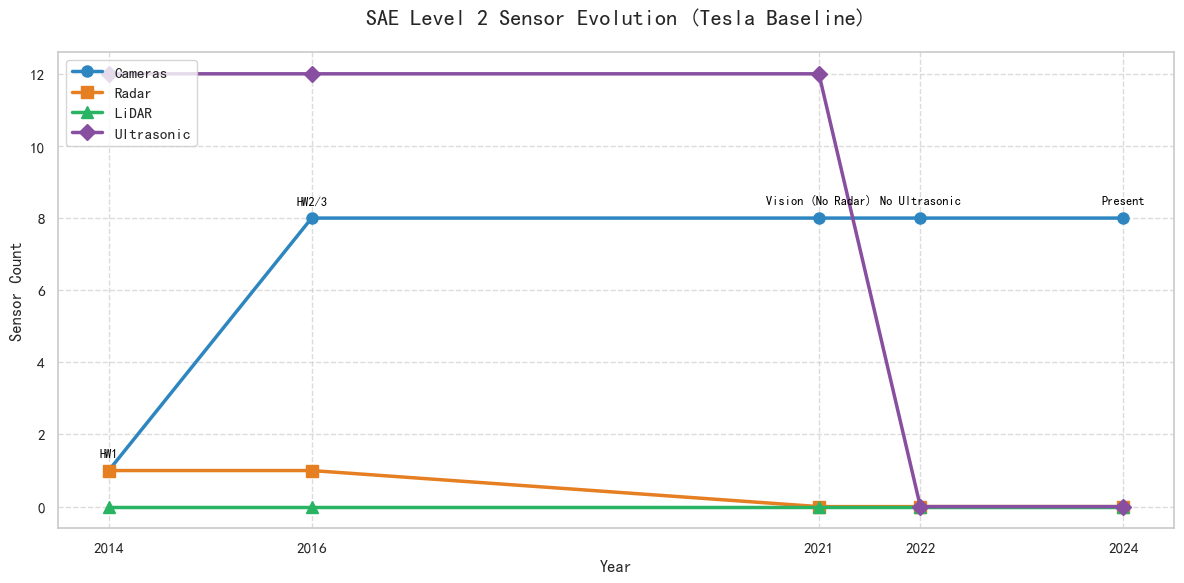

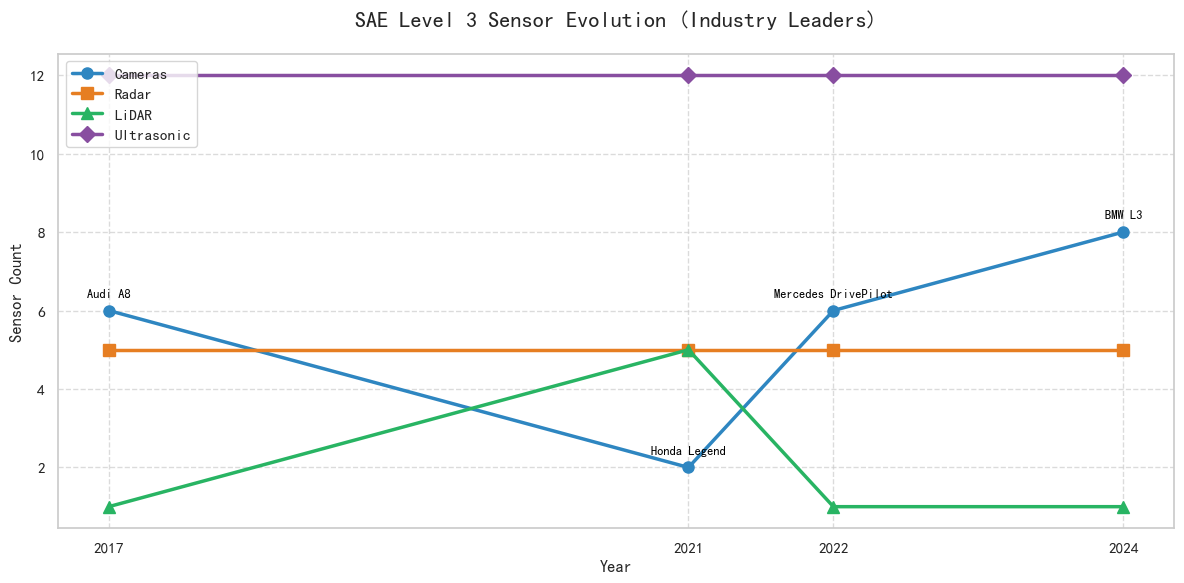

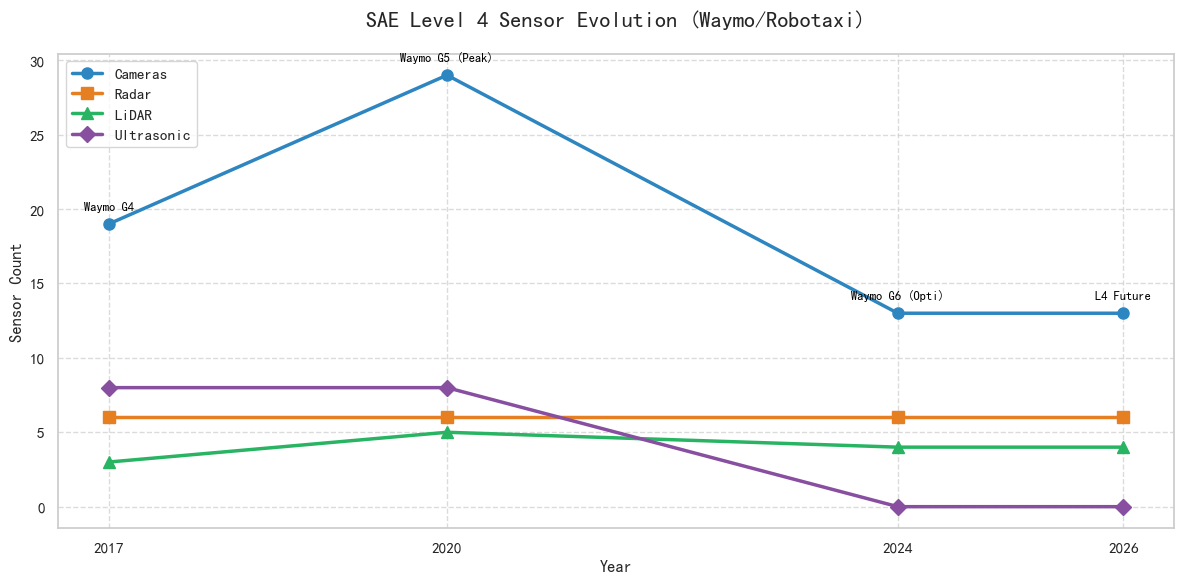

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # For Chinese characters if needed
plt.rcParams['axes.unicode_minus'] = False

# 1. DATA PREPARATION
# Level 2 Data (Tesla Evolution)
l2_data = {
    'Year': [2014, 2016, 2021, 2022, 2024],
    'Cameras': [1, 8, 8, 8, 8],
    'Radar': [1, 1, 0, 0, 0],
    'LiDAR': [0, 0, 0, 0, 0],
    'Ultrasonic': [12, 12, 12, 0, 0],
    'Milestone': ['HW1', 'HW2/3', 'Vision (No Radar)', 'No Ultrasonic', 'Present']
}

# Level 3 Data (Industry Benchmarks)
l3_data = {
    'Year': [2017, 2021, 2022, 2024],
    'Cameras': [6, 2, 6, 8],
    'Radar': [5, 5, 5, 5],
    'LiDAR': [1, 5, 1, 1],
    'Ultrasonic': [12, 12, 12, 12],
    'Milestone': ['Audi A8', 'Honda Legend', 'Mercedes DrivePilot', 'BMW L3']
}

# Level 4 Data (Waymo Evolution)
l4_data = {
    'Year': [2017, 2020, 2024, 2026],
    'Cameras': [19, 29, 13, 13],
    'Radar': [6, 6, 6, 6],
    'LiDAR': [3, 5, 4, 4],
    'Ultrasonic': [8, 8, 0, 0],
    'Milestone': ['Waymo G4', 'Waymo G5 (Peak)', 'Waymo G6 (Opti)', 'L4 Future']
}

df_l2 = pd.DataFrame(l2_data)
df_l3 = pd.DataFrame(l3_data)
df_l4 = pd.DataFrame(l4_data)

# 2. VISUALIZATION FUNCTION
def plot_sensors(df, title, colors):
    plt.figure(figsize=(12, 6))
    
    sensors = ['Cameras', 'Radar', 'LiDAR', 'Ultrasonic']
    markers = ['o', 's', '^', 'D']
    
    for i, sensor in enumerate(sensors):
        plt.plot(df['Year'], df[sensor], marker=markers[i], label=sensor, 
                 linewidth=2.5, markersize=8, color=colors[i])
        
        # Annotate points
        for x, y, label in zip(df['Year'], df[sensor], df['Milestone']):
            if sensor == 'Cameras': # Only show milestone label for the top line to avoid clutter
                plt.annotate(label, (x, y), textcoords="offset points", xytext=(0,10), 
                             ha='center', fontsize=9, fontweight='bold', color='black')

    plt.title(title, fontsize=16, pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Sensor Count', fontsize=12)
    plt.legend(frameon=True, loc='upper left')
    plt.xticks(df['Year'])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 3. GENERATE PLOTS
palette = ['#2E86C1', '#E67E22', '#28B463', '#884EA0'] # Blue, Orange, Green, Purple

# Plot L2
plot_sensors(df_l2, "SAE Level 2 Sensor Evolution (Tesla Baseline)", palette)

# Plot L3
plot_sensors(df_l3, "SAE Level 3 Sensor Evolution (Industry Leaders)", palette)

# Plot L4
plot_sensors(df_l4, "SAE Level 4 Sensor Evolution (Waymo/Robotaxi)", palette) 
